<a href="https://colab.research.google.com/github/bansalhim/Deep-learning-assignment/blob/main/Assignment_8_NEU_Surface_Defect_Database.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NEU Surface Defect Classification

This notebook studies the NEU Surface Defect Dataset for image classification.  
The goal is to understand the dataset, frame the problem correctly, train a CNN-based model, and evaluate its performance.

In [1]:
from google.colab import files
import zipfile, os

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
extract_path = "/content/neu_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Extracted folders/files:")
print(os.listdir(extract_path))

Saving archive (5).zip to archive (5).zip
Dataset extracted successfully.
Extracted folders/files:
['NEU-DET']


In [2]:
import os

for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:5])
    print("-" * 60)

Folder: /content/neu_dataset
Subfolders: ['NEU-DET']
Files: []
------------------------------------------------------------
Folder: /content/neu_dataset/NEU-DET
Subfolders: ['validation', 'train']
Files: []
------------------------------------------------------------
Folder: /content/neu_dataset/NEU-DET/validation
Subfolders: ['images', 'annotations']
Files: []
------------------------------------------------------------
Folder: /content/neu_dataset/NEU-DET/validation/images
Subfolders: ['patches', 'crazing', 'scratches', 'rolled-in_scale', 'pitted_surface', 'inclusion']
Files: []
------------------------------------------------------------
Folder: /content/neu_dataset/NEU-DET/validation/images/patches
Subfolders: []
Files: ['patches_299.jpg', 'patches_282.jpg', 'patches_280.jpg', 'patches_249.jpg', 'patches_253.jpg']
------------------------------------------------------------
Folder: /content/neu_dataset/NEU-DET/validation/images/crazing
Subfolders: []
Files: ['crazing_245.jpg', 'cra

In [3]:
base_dir = "/content/neu_dataset"

# If classes are inside another folder, update like this:
# base_dir = "/content/neu_dataset/NEU surface defect database"

print("Base directory:", base_dir)
print("Classes/Folders:", os.listdir(base_dir))

Base directory: /content/neu_dataset
Classes/Folders: ['NEU-DET']


In [31]:
import os

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')

def count_images(folder):
    counts = {}
    if not os.path.exists(folder):
        print(f"Warning: Folder does not exist: {folder}")
        return {}
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(
                [f for f in os.listdir(cls_path) if f.lower().endswith(valid_ext)]
            )
    return counts

extract_path = "/content/neu_dataset"
train_dir = os.path.join(extract_path, "NEU-DET", "train", "images")
val_dir = os.path.join(extract_path, "NEU-DET", "validation", "images")

print("Train counts:", count_images(train_dir))
print("Validation counts:", count_images(val_dir))

Train counts: {'patches': 240, 'crazing': 240, 'scratches': 240, 'rolled-in_scale': 240, 'pitted_surface': 240, 'inclusion': 240}
Validation counts: {'patches': 60, 'crazing': 60, 'scratches': 60, 'rolled-in_scale': 60, 'pitted_surface': 60, 'inclusion': 60}


## Dataset Observation

After checking sample images from each class, the images appear as grayscale steel surface images. The defects are mainly texture-based rather than object-based. Some classes contain line-like defects, some contain spot-like defects, and some show rough irregular surface areas.

Classes that may look similar:
- Crazing and Scratches: both contain line-like structures.
- Inclusion and Pitted Surface: both may show small dark spots.
- Patches and Rolled-in Scale: both have irregular rough regions.

Classes that are easier to separate:
- Scratches, because they usually have clear long line patterns.
- Pitted Surface, because it often has repeated hole-like marks.

The dataset is moderate/small because it contains 1800 images total with 300 images per class. This is enough for a basic experiment, but for deep learning models there is a risk of overfitting. Therefore, data augmentation and pretrained models are useful.

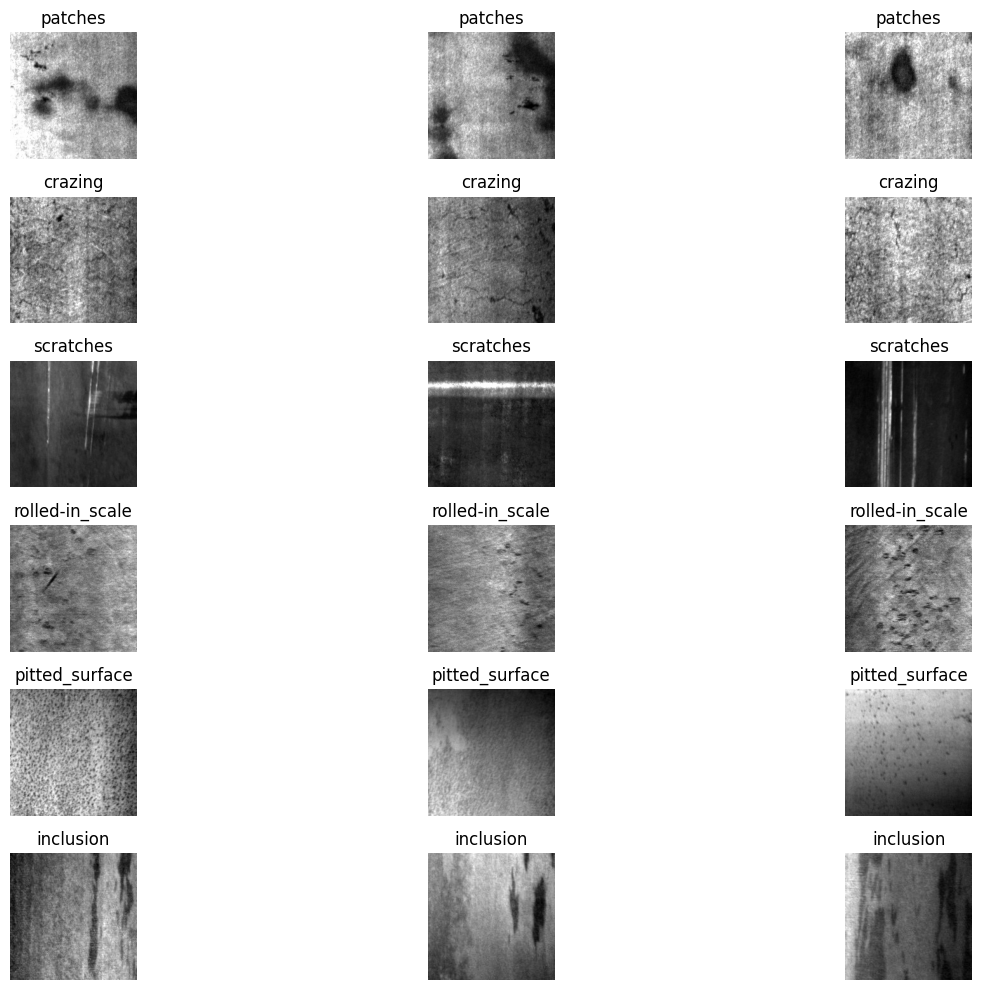

In [8]:
# now show sample images
import matplotlib.pyplot as plt
import cv2
import random

# Define the base directory for images, using the train_dir for sampling
image_base_dir = os.path.join(extract_path, "NEU-DET", "train", "images")

# Get the actual class names from the image_base_dir
classes = [c for c in os.listdir(image_base_dir) if os.path.isdir(os.path.join(image_base_dir, c))]

plt.figure(figsize=(15, 10))

plot_idx = 1

for cls in classes:
    cls_path = os.path.join(image_base_dir, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(valid_ext)]

    # Select a maximum of 3 images from each class
    selected = random.sample(imgs, min(3, len(imgs)))

    for img_name in selected:
        img_path = os.path.join(cls_path, img_name)
        # Read image in grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(len(classes), 3, plot_idx)
        plt.imshow(img, cmap='gray')
        plt.title(cls)
        plt.axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()

# For Question 4 to 6

## Problem Definition

### Input Space
The input is a grayscale steel surface image. Each image is a 2D spatial grid of pixel values. For model training, the images are resized to a fixed size such as 224 × 224.

### Output Space
The output is one of the six defect classes:
Crazing, Inclusion, Patches, Pitted Surface, Rolled-in Scale, and Scratches.

### Task Type
This is a multi-class image classification problem because each input image belongs to exactly one defect class.

# Answer 7

## Why Not Flatten the Image?

If the image is flattened from 2D into 1D, the spatial relationship between pixels is lost. This means the model may not understand which pixels are close to each other in the original image.

Flattening loses:
- Local texture information
- Edge structure
- 2D geometry
- Neighbor relationships
- Spatial patterns

Since this dataset depends strongly on texture, cracks, pits, and scratches, flattening is not ideal. A CNN is better because it preserves sptial informatin and learns local patterns using filters..

In [17]:
# now perpare data generator
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
print(class_names)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


# why to use CNN in this cae?

CNN is suitable for this dataset because the defect classes are mainly identified using local texture and pattern differences. CNN filters can detect edges, lines, spots, cracks, and rough regions.

Therefore, CNN is a natural choice for  surface defect classification.

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
import tensorflow as tf

custom_cnn = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = custom_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 518ms/step - accuracy: 0.3250 - loss: 1.8274 - val_accuracy: 0.1667 - val_loss: 1.8080
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 453ms/step - accuracy: 0.5167 - loss: 1.3001 - val_accuracy: 0.2778 - val_loss: 1.8143
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 475ms/step - accuracy: 0.6236 - loss: 1.0557 - val_accuracy: 0.2083 - val_loss: 1.8266
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 482ms/step - accuracy: 0.6458 - loss: 0.9803 - val_accuracy: 0.2111 - val_loss: 1.8464
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 467ms/step - accuracy: 0.6972 - loss: 0.8776 - val_accuracy: 0.2028 - val_loss: 1.8711
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 466ms/step - accuracy: 0.7257 - loss: 0.7826 - val_accuracy: 0.1611 - val_loss: 1.9167
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 487ms/step - accuracy: 0.7597 - loss: 0.7121 - val_accuracy: 0.1667 - val_loss: 1.9995
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 489ms/step - accuracy: 0.7646 - loss: 0.7029 - val_accu

Training Accuracy: 80.97%
Validation Accuracy: 56.67%
Validation Loss: 1.2838

The custom CNN achieved around 80.97% training accuracy and 56.67% validation accuracy.

However, there is still a gap between training and validation accuracy. This indicates partial overfitting, meaning the model learns the training images better than unseen validation images. This is expected because the NEU dataset is small and many defect classes have similar textures.

The result is acceptable for a first experiment, but it can be improved using stronger data augmentation, more regularization, fine-tuning, and testing other CNN architectures.

12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 771ms/step


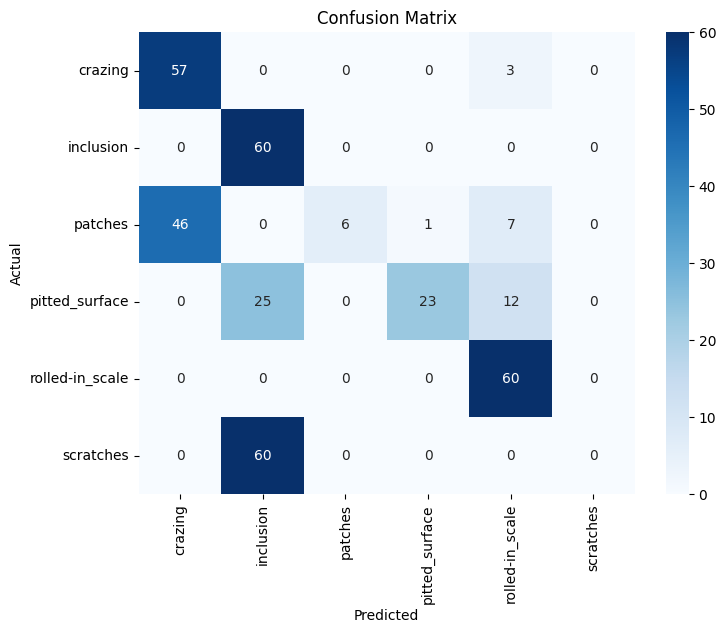

                 precision    recall  f1-score   support

        crazing       0.55      0.95      0.70        60
      inclusion       0.41      1.00      0.59        60
        patches       1.00      0.10      0.18        60
 pitted_surface       0.96      0.38      0.55        60
rolled-in_scale       0.73      1.00      0.85        60
      scratches       0.00      0.00      0.00        60

       accuracy                           0.57       360
      macro avg       0.61      0.57      0.48       360
   weighted avg       0.61      0.57      0.48       360



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

val_data.reset()

pred_probs = custom_cnn.predict(val_data)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [35]:
#resnet 50
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_resnet = train_gen.flow_from_directory(train_dir, target_size=(224,224), batch_size=32, class_mode='categorical')
val_resnet = val_gen.flow_from_directory(val_dir, target_size=(224,224), batch_size=32, class_mode='categorical')

base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.4)(x)
out = Dense(6, activation='softmax')(x)

resnet_model = Model(base.input, out)

resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

resnet_history = resnet_model.fit(train_resnet, validation_data=val_resnet, epochs=5)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.
Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 38s 587ms/step - accuracy: 0.7319 - loss: 0.7942 - val_accuracy: 0.9389 - val_loss: 0.1955
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 417ms/step - accuracy: 0.9688 - loss: 0.1401 - val_accuracy: 0.9417 - val_loss: 0.1550
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 417ms/step - accuracy: 0.9882 - loss: 0.0761 - val_accuracy: 0.9694 - val_loss: 0.0935
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 439ms/step - accuracy: 0.9917 - loss: 0.0566 - val_accuracy: 0.9694 - val_loss: 0.0845
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 421ms/step - accuracy: 0.9931 - loss: 0.0425 - val_accuracy: 0.9889 - val_loss: 0.0616


The   model is performing good achieved 99.31% training accuracy and 98.89% validation accuracy after 5 epochs. The validation loss also decreased to 0.0616, showing that the model learned strong defect features and generalized well on the validation set.

This result is much better than the custom CNN, which had lower validation accuracy. The improvement happened because this pretrained model already had useful feature extraction capability, and after using correct preprocessing, it was able to learn the NEU defect patterns effectively.

In [36]:
#MobileVNet v2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_mob = train_gen.flow_from_directory(train_dir, target_size=(224,224), batch_size=32)
val_mob = val_gen.flow_from_directory(val_dir, target_size=(224,224), batch_size=32)

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
out = Dense(6, activation='softmax')(x)

mob_model = Model(base.input, out)

mob_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

mob_history = mob_model.fit(train_mob, validation_data=val_mob, epochs=5)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.
Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 352ms/step - accuracy: 0.8493 - loss: 0.5743 - val_accuracy: 0.9778 - val_loss: 0.1808
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9917 - loss: 0.0962 - val_accuracy: 0.9889 - val_loss: 0.1127
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.9951 - loss: 0.0560 - val_accuracy: 0.9944 - val_loss: 0.0828
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9965 - loss: 0.0387 - val_accuracy: 0.9944 - val_loss: 0.0656
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9972 - loss: 0.0298 - val_accuracy: 0.9944 - val_loss: 0.0530


In [37]:
#Efficient
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_eff = train_gen.flow_from_directory(train_dir, target_size=(224,224), batch_size=32)
val_eff = val_gen.flow_from_directory(val_dir, target_size=(224,224), batch_size=32)

base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
out = Dense(6, activation='softmax')(x)

eff_model = Model(base.input, out)

eff_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

eff_history = eff_model.fit(train_eff, validation_data=val_eff, epochs=5)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.
Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 335ms/step - accuracy: 0.7639 - loss: 1.0478 - val_accuracy: 0.9389 - val_loss: 0.6251
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9681 - loss: 0.3558 - val_accuracy: 0.9583 - val_loss: 0.3719
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9778 - loss: 0.2135 - val_accuracy: 0.9639 - val_loss: 0.2509
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9861 - loss: 0.1488 - val_accuracy: 0.9750 - val_loss: 0.1972
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9882 - loss: 0.1158 - val_accuracy: 0.9722 - val_loss: 0.1823


## Model Comparison

Multiple pretrained models were evaluated on the NEU Surface Defect Dataset.

MobileNetV2 achieved the highest validation accuracy of 99.44% with the lowest validation loss. This indicates that the model was able to learn discriminative texture features effectively and generalize well on the validation data.

EfficientNetB0 also performed well with a validation accuracy of 97.22%, but it was slightly lower than MobileNetV2. This suggests that although EfficientNet is powerful, MobileNetV2 was more suitable for this dataset in this experiment.

Both models significantly outperformed the custom CNN, showing that transfer learning is highly effective for this dataset.

In [38]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Custom CNN", "ResNet50", "MobileNetV2", "EfficientNetB0"],
    "Validation Accuracy": [0.5667, 0.9889, 0.9944, 0.9722],
    "Validation Loss": [1.2838, 0.0616, 0.0530, 0.1823]
})

results

,Model,Validation Accuracy,Validation Loss
0,Custom CNN,0.5667,1.2838
1,ResNet50,0.9889,0.0616
2,MobileNetV2,0.9944,0.0530
3,EfficientNetB0,0.9722,0.1823


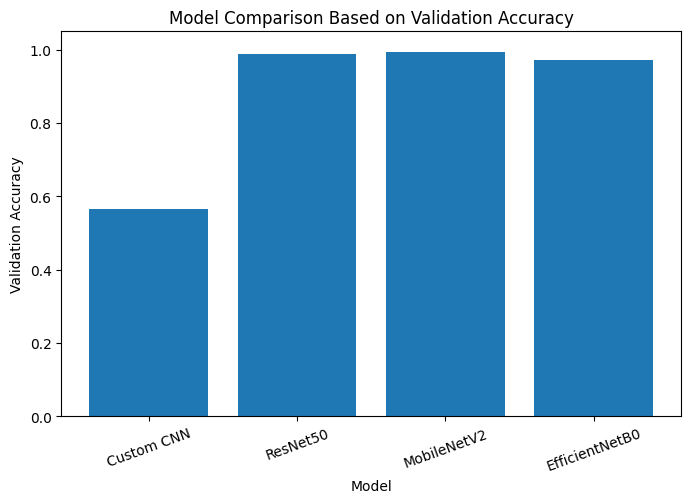

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Validation Accuracy"])
plt.title("Model Comparison Based on Validation Accuracy")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.show()

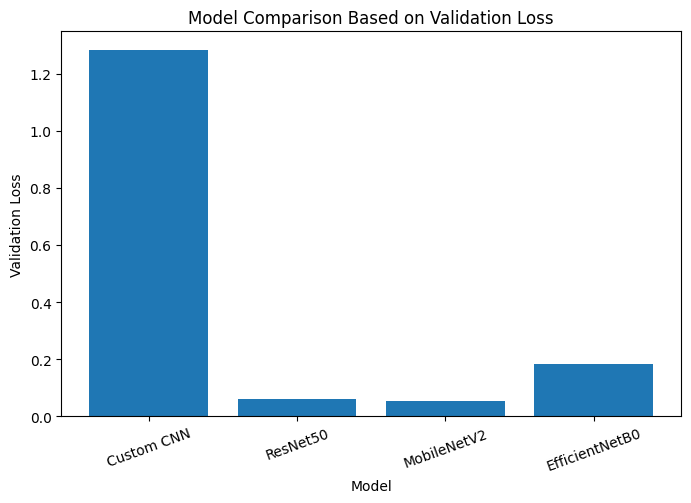

In [40]:
# comparison graph for loss
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Validation Loss"])
plt.title("Model Comparison Based on Validation Loss")
plt.xlabel("Model")
plt.ylabel("Validation Loss")
plt.xticks(rotation=20)
plt.show()

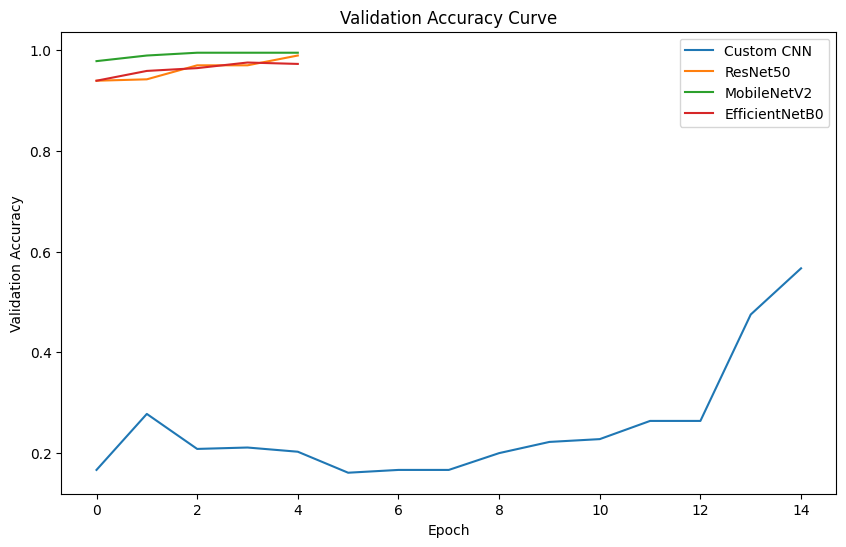

In [41]:
# accuracy curve for each model
plt.figure(figsize=(10,6))

plt.plot(history.history['val_accuracy'], label='Custom CNN')
plt.plot(resnet_history.history['val_accuracy'], label='ResNet50')
plt.plot(mob_history.history['val_accuracy'], label='MobileNetV2')
plt.plot(eff_history.history['val_accuracy'], label='EfficientNetB0')

plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

## Model Comparison

Four models were tested on the NEU Surface Defect Dataset: Custom CNN, ResNet50, MobileNetV2, and EfficientNetB0.

The Custom CNN achieved around 56.67% validation accuracy. It was able to learn some texture features, but the gap between training and validation performance showed partial overfitting.

ResNet50 performed much better with around 98.89% validation accuracy. This improvement happened because ResNet uses residual connections, which help deeper networks learn stable feature representations.

MobileNetV2 gave the best result with around 99.44% validation accuracy and the lowest validation loss. This shows that a lightweight pretrained model can work very effectively on this dataset.

EfficientNetB0 also performed well with around 97.22% validation accuracy, but it was slightly lower than MobileNetV2 in this experiment.

## Q8. Which model would you start with?

I would start with MobileNetV2 because it gave the best validation accuracy in this experiment. It is lightweight, efficient, and suitable for a moderate-sized dataset like NEU.

## Q9. Why this model?

MobileNetV2 is selected because it provides a good balance between accuracy and computational efficiency. It uses depthwise separable convolutions, which reduce the number of parameters while still learning useful image features.

This matters for the NEU dataset because the images are texture-based and the dataset size is not very large. MobileNetV2 can capture cracks, scratches, pits, and rough surface patterns without becoming unnecessarily heavy.

## Q10. Why not the others?

The Custom CNN was useful as a baseline, but it showed lower validation accuracy and overfitting.

ResNet50 performed very well, but it is heavier than MobileNetV2 and requires more computation.

EfficientNetB0 also performed well, but in this experiment its validation accuracy was slightly lower than MobileNetV2.

Therefore, MobileNetV2 was selected as the best model because it achieved the highest validation accuracy with an efficient architecture.

## Q11. Is accuracy enough?

No, accuracy alone is not enough. Accuracy gives only the overall performance, but it does not show which classes are being misclassified.

For this dataset, some classes are visually similar, such as crazing and scratches or inclusion and pitted surface. Therefore, confusion matrix, precision, recall, and F1-score are also needed to understand class-wise performance.

## Q12. What does the confusion matrix tell you?

The confusion matrix shows how many images from each actual class were predicted correctly or incorrectly. It helps identify which defect classes are being confused by the model.

In surface defect classification, this is important because some defects have similar texture patterns. The confusion matrix helps us check whether the model is confusing similar classes like scratches with crazing or pitted surface with inclusion.

## Q13. Where will the model fail?

The model may fail when two defect classes have similar textures.

Expected failure cases:
1. Crazing and scratches, because both contain line-like patterns.
2. Inclusion and pitted surface, because both may contain small dark spot-like patterns.
3. Patches and rolled-in scale, because both show irregular rough texture.

The model may also fail on real-world images with different lighting, camera angle, noise, or defect severity.

## Q14. What will you change?

To improve the model further, I would use stronger data augmentation, fine-tune some pretrained layers, add early stopping, and test the model on external unseen industrial images.

I would also analyze the confusion matrix to find weak classes and apply class-wise improvements if some classes are misclassified more often.

## Final Conclusion

The NEU Surface Defect Dataset is a six-class image classification problem where the main challenge is fine texture recognition. The dataset is balanced, but some classes have similar visual patterns.

The Custom CNN worked as a basic baseline but did not generalize very well. Pretrained models performed much better after correct preprocessing. Among all models, MobileNetV2 achieved the best result with 99.44% validation accuracy and the lowest validation loss.

Therefore, MobileNetV2 was selected as the best model for this experiment. However, before real industrial deployment, the model should be tested on external images with different lighting, noise, and surface conditions.